Epoch 0: D Loss: 1.3979, G Loss: -0.8271,G Grad Norm^2: 1.037356
Epoch 100: D Loss: 1.1618, G Loss: -0.6287,G Grad Norm^2: 0.078870
Epoch 200: D Loss: 1.1171, G Loss: -0.4331,G Grad Norm^2: 1.399457
Epoch 300: D Loss: 1.4164, G Loss: -0.6822,G Grad Norm^2: 1.609830
Epoch 400: D Loss: 1.0720, G Loss: -0.4555,G Grad Norm^2: 1.562002
Epoch 500: D Loss: 1.1109, G Loss: -0.3458,G Grad Norm^2: 1.730689
Epoch 600: D Loss: 1.1958, G Loss: -0.7163,G Grad Norm^2: 1.710752
Epoch 700: D Loss: 1.0773, G Loss: -0.5037,G Grad Norm^2: 1.594908
Epoch 800: D Loss: 1.0512, G Loss: -0.3682,G Grad Norm^2: 2.055288
Epoch 900: D Loss: 1.0824, G Loss: -0.5267,G Grad Norm^2: 2.129892
Epoch 1000: D Loss: 1.1252, G Loss: -0.3721,G Grad Norm^2: 2.559874
Epoch 1100: D Loss: 1.2127, G Loss: -0.6485,G Grad Norm^2: 2.492993
Epoch 1200: D Loss: 1.1880, G Loss: -0.3790,G Grad Norm^2: 2.660069
Epoch 1300: D Loss: 1.0955, G Loss: -0.6004,G Grad Norm^2: 2.577080
Epoch 1400: D Loss: 1.0018, G Loss: -0.3433,G Grad Norm^2: 2

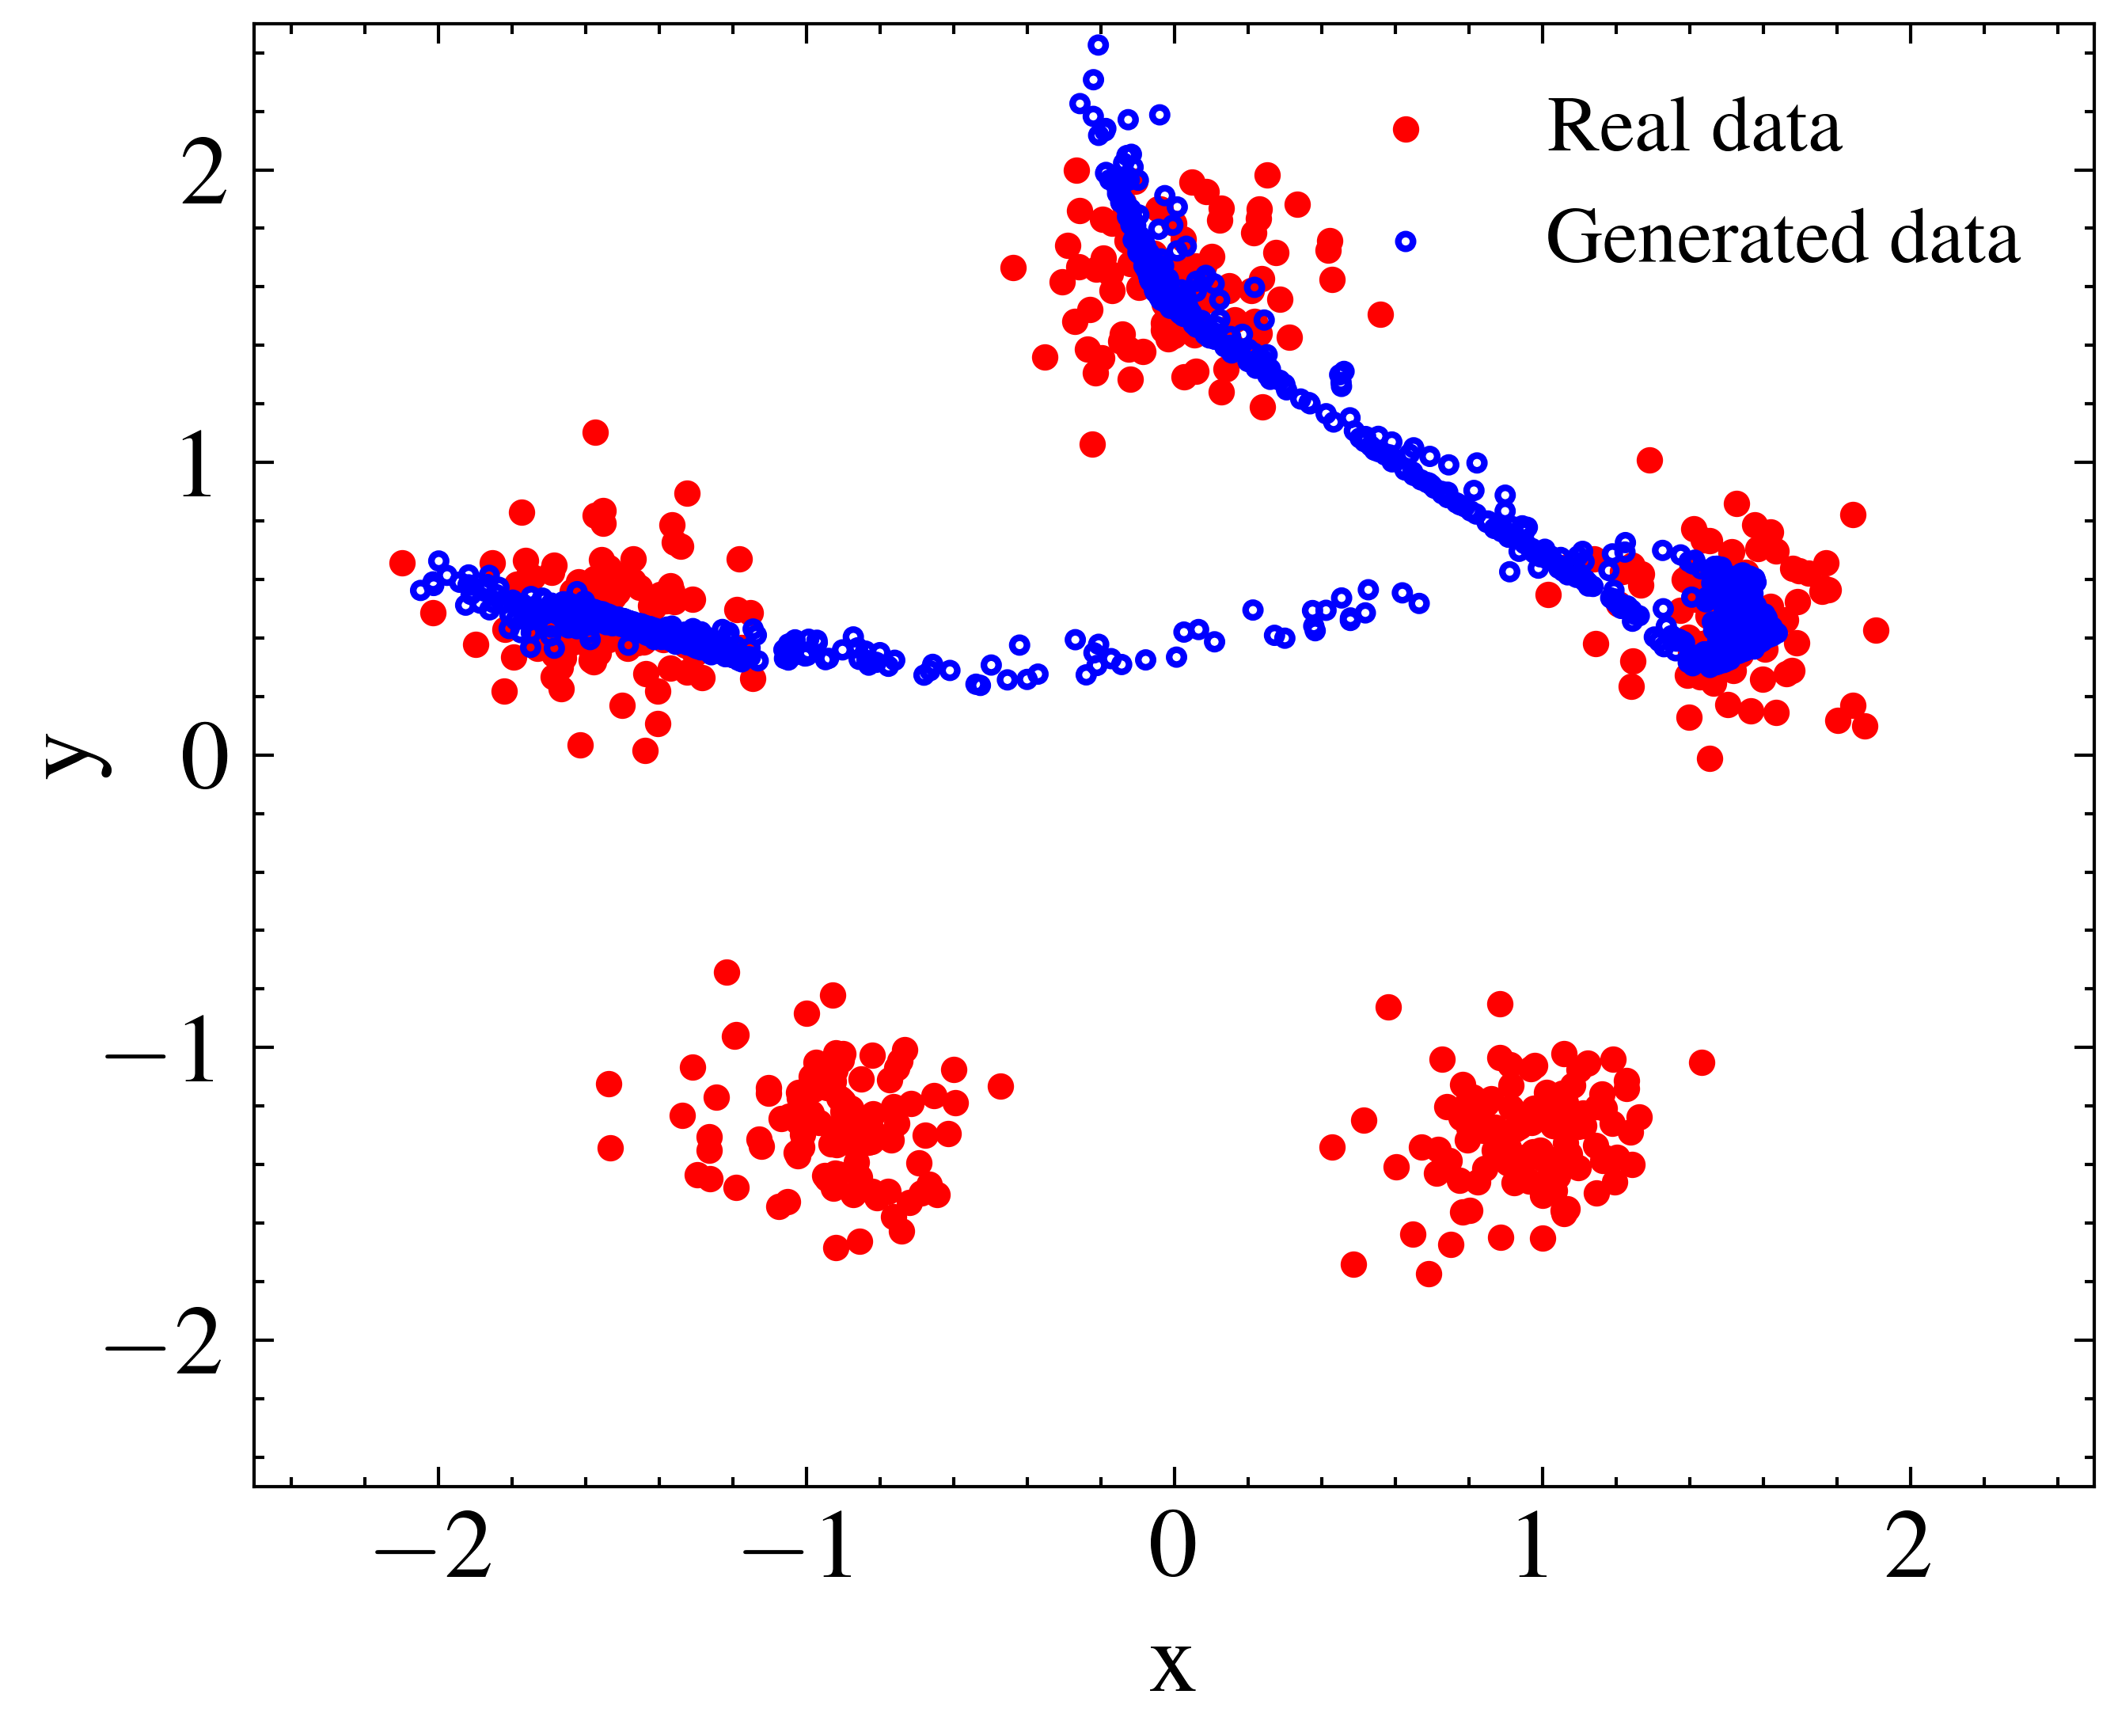


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.4120
Precision（生成样本落入真实密度区域比例）: 0.8400
生成样本已保存为 generated_samples1.npy
生成器梯度范数已保存为 generator_grad_norm_squared.npy


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 683  ###########连续5次随机种子看看是否成功42, 23,
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

epoch_generator_grad_norm = []
# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()

        total_norm = 0.0
        for p in generator.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2) ** 2  # L2 norm squared
                total_norm += param_norm.item()
        batch_generator_grad_norm.append(total_norm)
        
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_generator_grad_norm.append(np.mean(batch_generator_grad_norm))

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f},"
              f"G Grad Norm^2: {np.mean(batch_generator_grad_norm):.6f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }
# 生成样本
samples = generator(torch.randn(1000, z_dim)).detach()

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")




samples = generator(torch.randn(1000, z_dim)).detach().numpy()
np.save("D:/PRE2025/generated_samples1.npy", samples)
print("生成样本已保存为 generated_samples1.npy")
np.save("D:/PRE2025/generator_grad_norm_squared.npy", np.array(epoch_generator_grad_norm))
print("生成器梯度范数已保存为 generator_grad_norm_squared.npy")

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 683###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class GEU(nn.Module):
    def __init__(self, init_sigma=1.0):  # 建议默认值就写 1.0（浮点数）
        super(GEU, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = (1 + torch.erf(input / (torch.sqrt(torch.tensor(2.0)) * sigma_safe))) / 2
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.GEU = GEU()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.GEU(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }
# 生成样本
samples = generator(torch.randn(1000, z_dim)).detach()

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

Epoch 0: D Loss: 1.4205, G Loss: -0.9144


KeyboardInterrupt: 

In [ ]:
print("Final sigma:", discriminator.GEU.sigma.item())

d:\anaconda\envs\torch2\lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



           GAN 质量评价报告

1. k-NN 分类精度 (越接近0.5越好):
   1NN_acc: 1.0000
   3NN_acc: 0.8713
   5NN_acc: 0.8367

2. Coverage 分数 (越高越好):
   Coverage_eps0.05: 0.5360
   Coverage_eps0.1: 0.7680
   Coverage_eps0.2: 0.9520

3. Precision 分数 (越高越好):
   Precision_eps0.05: 0.7420
   Precision_eps0.1: 0.9270
   Precision_eps0.2: 0.9660

4. Wasserstein 距离:
   维度 0: 0.1452
   维度 1: 0.0904
   平均值: 0.1178

5. 分布统计:
   均值差异: 0.1494
   标准差差异: 0.0372
   最近邻距离差异: 0.0255

6. 模式分析:
   真实数据模式数: 5
   生成数据模式数: 5
   模式数差异: 0

7. 综合评价:
   质量得分: 0.6083 (0-1, 越高越好)
   评级: 良好


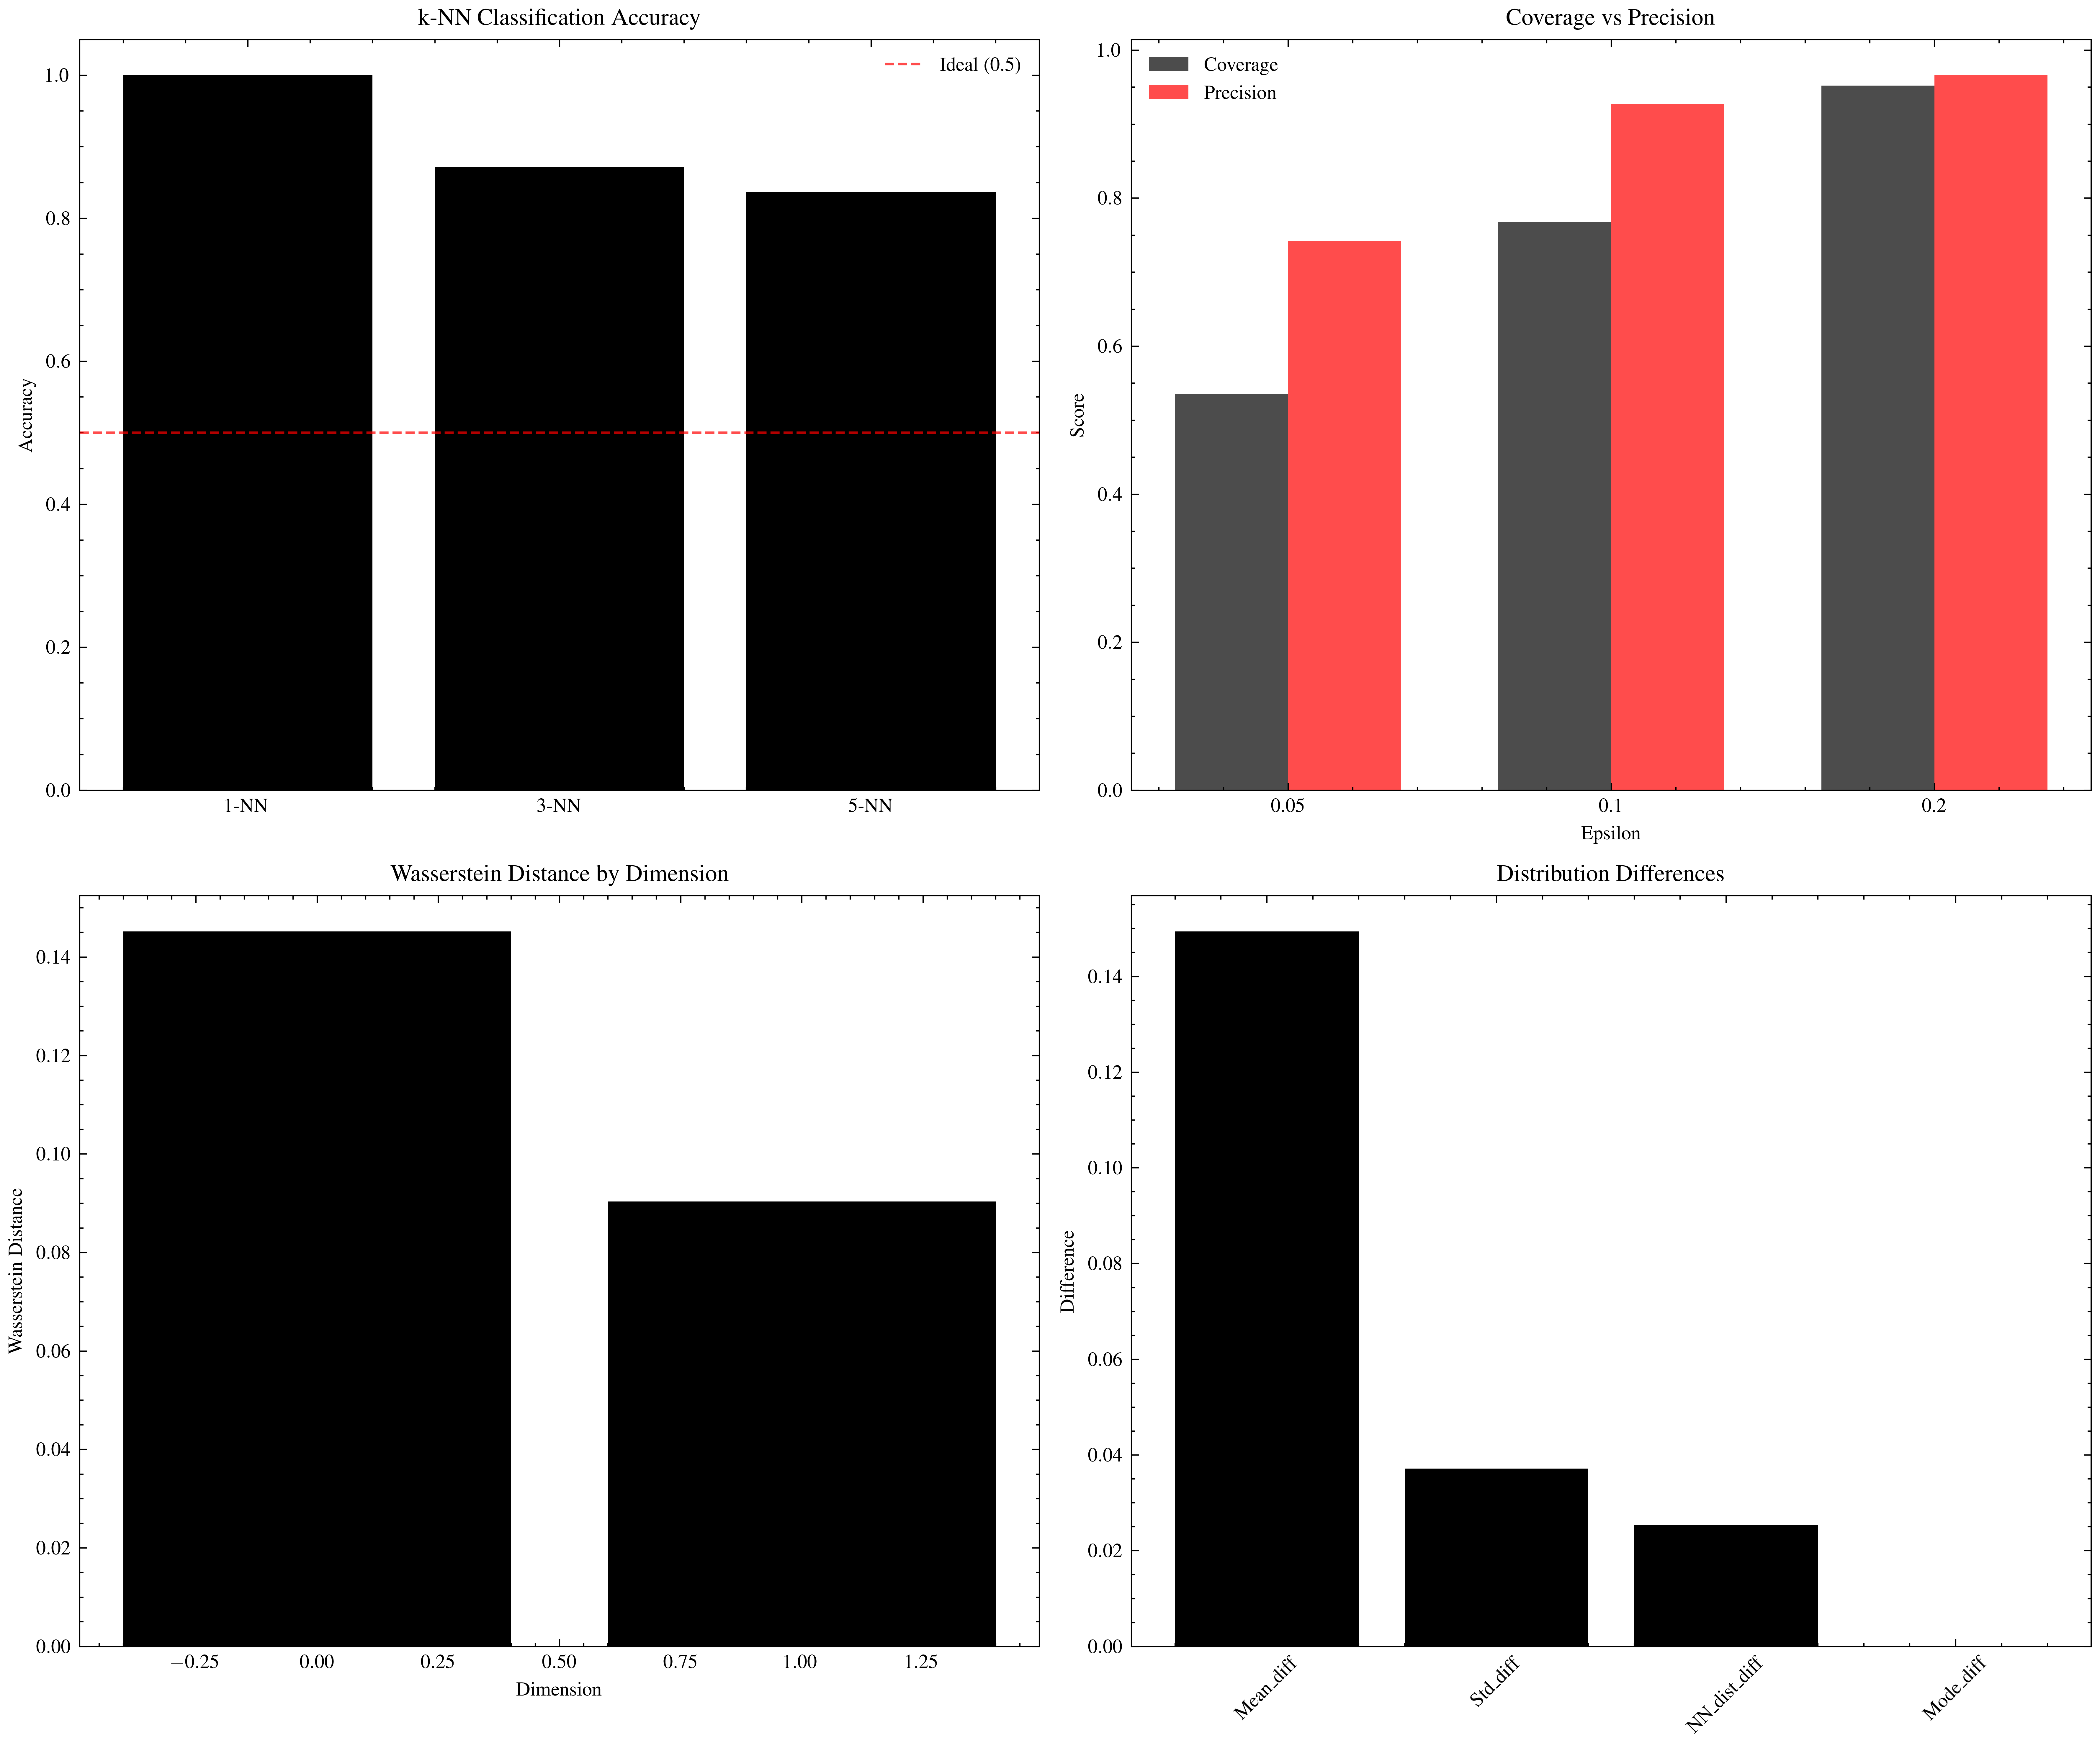

In [9]:
import torch
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

def comprehensive_gan_evaluation(X_real, X_fake, eps_list=[0.05, 0.1, 0.2], k_list=[1, 3, 5]):
    """
    综合评价 GAN 的输出质量

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps_list: 多个距离阈值
    - k_list: 多个k值用于k-NN

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    results = {}

    # ------------------------------
    # 1. 多尺度 k-NN 分类精度
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn_results = {}
    for k in k_list:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_all, y_all)
        y_pred = knn.predict(X_all)
        acc = accuracy_score(y_all, y_pred)
        knn_acc = max(acc, 1 - acc)
        knn_results[f'{k}NN_acc'] = knn_acc

    results['kNN_scores'] = knn_results

    # ------------------------------
    # 2. 多尺度 Coverage 和 Precision
    # ------------------------------
    coverage_results = {}
    precision_results = {}

    for eps in eps_list:
        dists_real_to_fake = cdist(X_real, X_fake)
        min_dists_real = np.min(dists_real_to_fake, axis=1)
        coverage = np.mean(min_dists_real < eps)
        coverage_results[f'Coverage_eps{eps}'] = coverage

        dists_fake_to_real = cdist(X_fake, X_real)
        min_dists_fake = np.min(dists_fake_to_real, axis=1)
        precision = np.mean(min_dists_fake < eps)
        precision_results[f'Precision_eps{eps}'] = precision

    results['Coverage'] = coverage_results
    results['Precision'] = precision_results

    # ------------------------------
    # 3. Wasserstein Distance (每个维度)
    # ------------------------------
    wasserstein_distances = []
    for dim in range(X_real.shape[1]):
        wd = wasserstein_distance(X_real[:, dim], X_fake[:, dim])
        wasserstein_distances.append(wd)

    results['Wasserstein_distances'] = wasserstein_distances
    results['Mean_Wasserstein'] = np.mean(wasserstein_distances)

    # ------------------------------
    # 4. 分布统计比较
    # ------------------------------
    real_mean = np.mean(X_real, axis=0)
    fake_mean = np.mean(X_fake, axis=0)
    real_std = np.std(X_real, axis=0)
    fake_std = np.std(X_fake, axis=0)

    mean_diff = np.linalg.norm(real_mean - fake_mean)
    std_diff = np.linalg.norm(real_std - fake_std)

    results['Mean_difference'] = mean_diff
    results['Std_difference'] = std_diff

    # ------------------------------
    # 5. 最近邻距离分布比较
    # ------------------------------
    real_nn_dists = []
    for i in range(len(X_real)):
        dists = np.linalg.norm(X_real - X_real[i], axis=1)
        dists = dists[dists > 0]
        real_nn_dists.append(np.min(dists))

    fake_nn_dists = []
    for i in range(len(X_fake)):
        dists = np.linalg.norm(X_fake - X_fake[i], axis=1)
        dists = dists[dists > 0]
        fake_nn_dists.append(np.min(dists))

    nn_dist_diff = wasserstein_distance(real_nn_dists, fake_nn_dists)
    results['NN_distance_difference'] = nn_dist_diff

    # ------------------------------
    # 6. 模式数量估计
    # ------------------------------
    def estimate_modes(X, n_modes=5):
        X = X.cpu().detach().numpy() if torch.is_tensor(X) else X
        gmm = GaussianMixture(n_components=n_modes, random_state=42)
        gmm.fit(X)
        return n_modes, gmm.means_

    real_modes_n, _ = estimate_modes(X_real, n_modes=5)
    fake_modes_n, _ = estimate_modes(X_fake, n_modes=5)

    results['Real_modes'] = real_modes_n
    results['Fake_modes'] = fake_modes_n
    results['Mode_difference'] = abs(real_modes_n - fake_modes_n)

    return results


def plot_evaluation_results(results):
    """可视化评价结果"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. k-NN
    ax1 = axes[0, 0]
    knn_scores = results['kNN_scores']
    k_values = [int(k.replace('NN_acc', '')) for k in knn_scores.keys()]
    scores = list(knn_scores.values())
    ax1.bar(range(len(k_values)), scores)
    ax1.set_xticks(range(len(k_values)))
    ax1.set_xticklabels([f'{k}-NN' for k in k_values])
    ax1.set_ylabel('Accuracy')
    ax1.set_title('k-NN Classification Accuracy')
    ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Ideal (0.5)')
    ax1.legend()

    # 2. Coverage & Precision
    ax2 = axes[0, 1]
    coverage_scores = list(results['Coverage'].values())
    precision_scores = list(results['Precision'].values())
    eps_values = [float(e.split("eps")[1]) for e in results['Coverage'].keys()]
    x = np.arange(len(eps_values))
    width = 0.35
    ax2.bar(x - width/2, coverage_scores, width, label='Coverage', alpha=0.7)
    ax2.bar(x + width/2, precision_scores, width, label='Precision', alpha=0.7)
    ax2.set_xlabel('Epsilon')
    ax2.set_ylabel('Score')
    ax2.set_title('Coverage vs Precision')
    ax2.set_xticks(x)
    ax2.set_xticklabels(eps_values)
    ax2.legend()

    # 3. Wasserstein
    ax3 = axes[1, 0]
    wd_scores = results['Wasserstein_distances']
    ax3.bar(range(len(wd_scores)), wd_scores)
    ax3.set_xlabel('Dimension')
    ax3.set_ylabel('Wasserstein Distance')
    ax3.set_title('Wasserstein Distance by Dimension')

    # 4. 统计量
    ax4 = axes[1, 1]
    metrics = ['Mean_diff', 'Std_diff', 'NN_dist_diff', 'Mode_diff']
    values = [
        results['Mean_difference'],
        results['Std_difference'],
        results['NN_distance_difference'],
        results['Mode_difference']
    ]
    ax4.bar(range(len(metrics)), values)
    ax4.set_ylabel('Difference')
    ax4.set_title('Distribution Differences')
    ax4.set_xticks(range(len(metrics)))
    ax4.set_xticklabels(metrics, rotation=45)

    plt.tight_layout()
    plt.show()


def print_evaluation_summary(results):
    """打印评价摘要"""
    print("\n" + "="*50)
    print("           GAN 质量评价报告")
    print("="*50)

    print("\n1. k-NN 分类精度 (越接近0.5越好):")
    for k, score in results['kNN_scores'].items():
        print(f"   {k}: {score:.4f}")

    print("\n2. Coverage 分数 (越高越好):")
    for eps, score in results['Coverage'].items():
        print(f"   {eps}: {score:.4f}")

    print("\n3. Precision 分数 (越高越好):")
    for eps, score in results['Precision'].items():
        print(f"   {eps}: {score:.4f}")

    print(f"\n4. Wasserstein 距离:")
    for i, wd in enumerate(results['Wasserstein_distances']):
        print(f"   维度 {i}: {wd:.4f}")
    print(f"   平均值: {results['Mean_Wasserstein']:.4f}")

    print(f"\n5. 分布统计:")
    print(f"   均值差异: {results['Mean_difference']:.4f}")
    print(f"   标准差差异: {results['Std_difference']:.4f}")
    print(f"   最近邻距离差异: {results['NN_distance_difference']:.4f}")

    print(f"\n6. 模式分析:")
    print(f"   真实数据模式数: {results['Real_modes']}")
    print(f"   生成数据模式数: {results['Fake_modes']}")
    print(f"   模式数差异: {results['Mode_difference']}")

    # 综合评分
    knn_score = np.mean(list(results['kNN_scores'].values()))
    coverage_score = np.mean(list(results['Coverage'].values()))
    precision_score = np.mean(list(results['Precision'].values()))
    knn_quality = 1 - 2 * abs(knn_score - 0.5)
    overall_score = (knn_quality + coverage_score + precision_score) / 3

    print(f"\n7. 综合评价:")
    print(f"   质量得分: {overall_score:.4f} (0-1, 越高越好)")

    if overall_score > 0.8:
        print("   评级: 优秀")
    elif overall_score > 0.6:
        print("   评级: 良好")
    elif overall_score > 0.4:
        print("   评级: 中等")
    else:
        print("   评级: 需要改进")

# -----------------------------
# 示例调用（你需要替换以下内容）：
# -----------------------------
# 请确保定义了 generator 和 z_dim，并且 X_train 是真实数据张量
samples = generator(torch.randn(1000, 2)).detach()

results = comprehensive_gan_evaluation(X_train, samples)
print_evaluation_summary(results)
plot_evaluation_results(results)


Epoch 0: D Loss: 1.4418, G Loss: -0.9754
Epoch 100: D Loss: 1.1325, G Loss: -0.6026
Epoch 200: D Loss: 0.8827, G Loss: -0.3030
Epoch 300: D Loss: 1.5932, G Loss: -1.0864
Epoch 400: D Loss: 0.6828, G Loss: -0.2422
Epoch 500: D Loss: 1.2761, G Loss: -0.5814
Epoch 600: D Loss: 1.2501, G Loss: -0.4193
Epoch 700: D Loss: 0.8638, G Loss: -0.4009
Epoch 800: D Loss: 0.9052, G Loss: -0.3875
Epoch 900: D Loss: 0.7708, G Loss: -0.3098
Epoch 1000: D Loss: 1.1062, G Loss: -0.4943
Epoch 1100: D Loss: 1.0638, G Loss: -0.5299
Epoch 1200: D Loss: 0.9811, G Loss: -0.4882
Epoch 1300: D Loss: 0.8751, G Loss: -0.4406
Epoch 1400: D Loss: 0.9808, G Loss: -0.5384
Epoch 1500: D Loss: 0.9365, G Loss: -0.5079
Epoch 1600: D Loss: 0.9895, G Loss: -0.5243
Epoch 1700: D Loss: 1.0259, G Loss: -0.5375
Epoch 1800: D Loss: 1.0439, G Loss: -0.5407
Epoch 1900: D Loss: 1.0959, G Loss: -0.5926
Epoch 2000: D Loss: 1.1221, G Loss: -0.5844
Epoch 2100: D Loss: 1.1495, G Loss: -0.6021
Epoch 2200: D Loss: 1.1629, G Loss: -0.5963


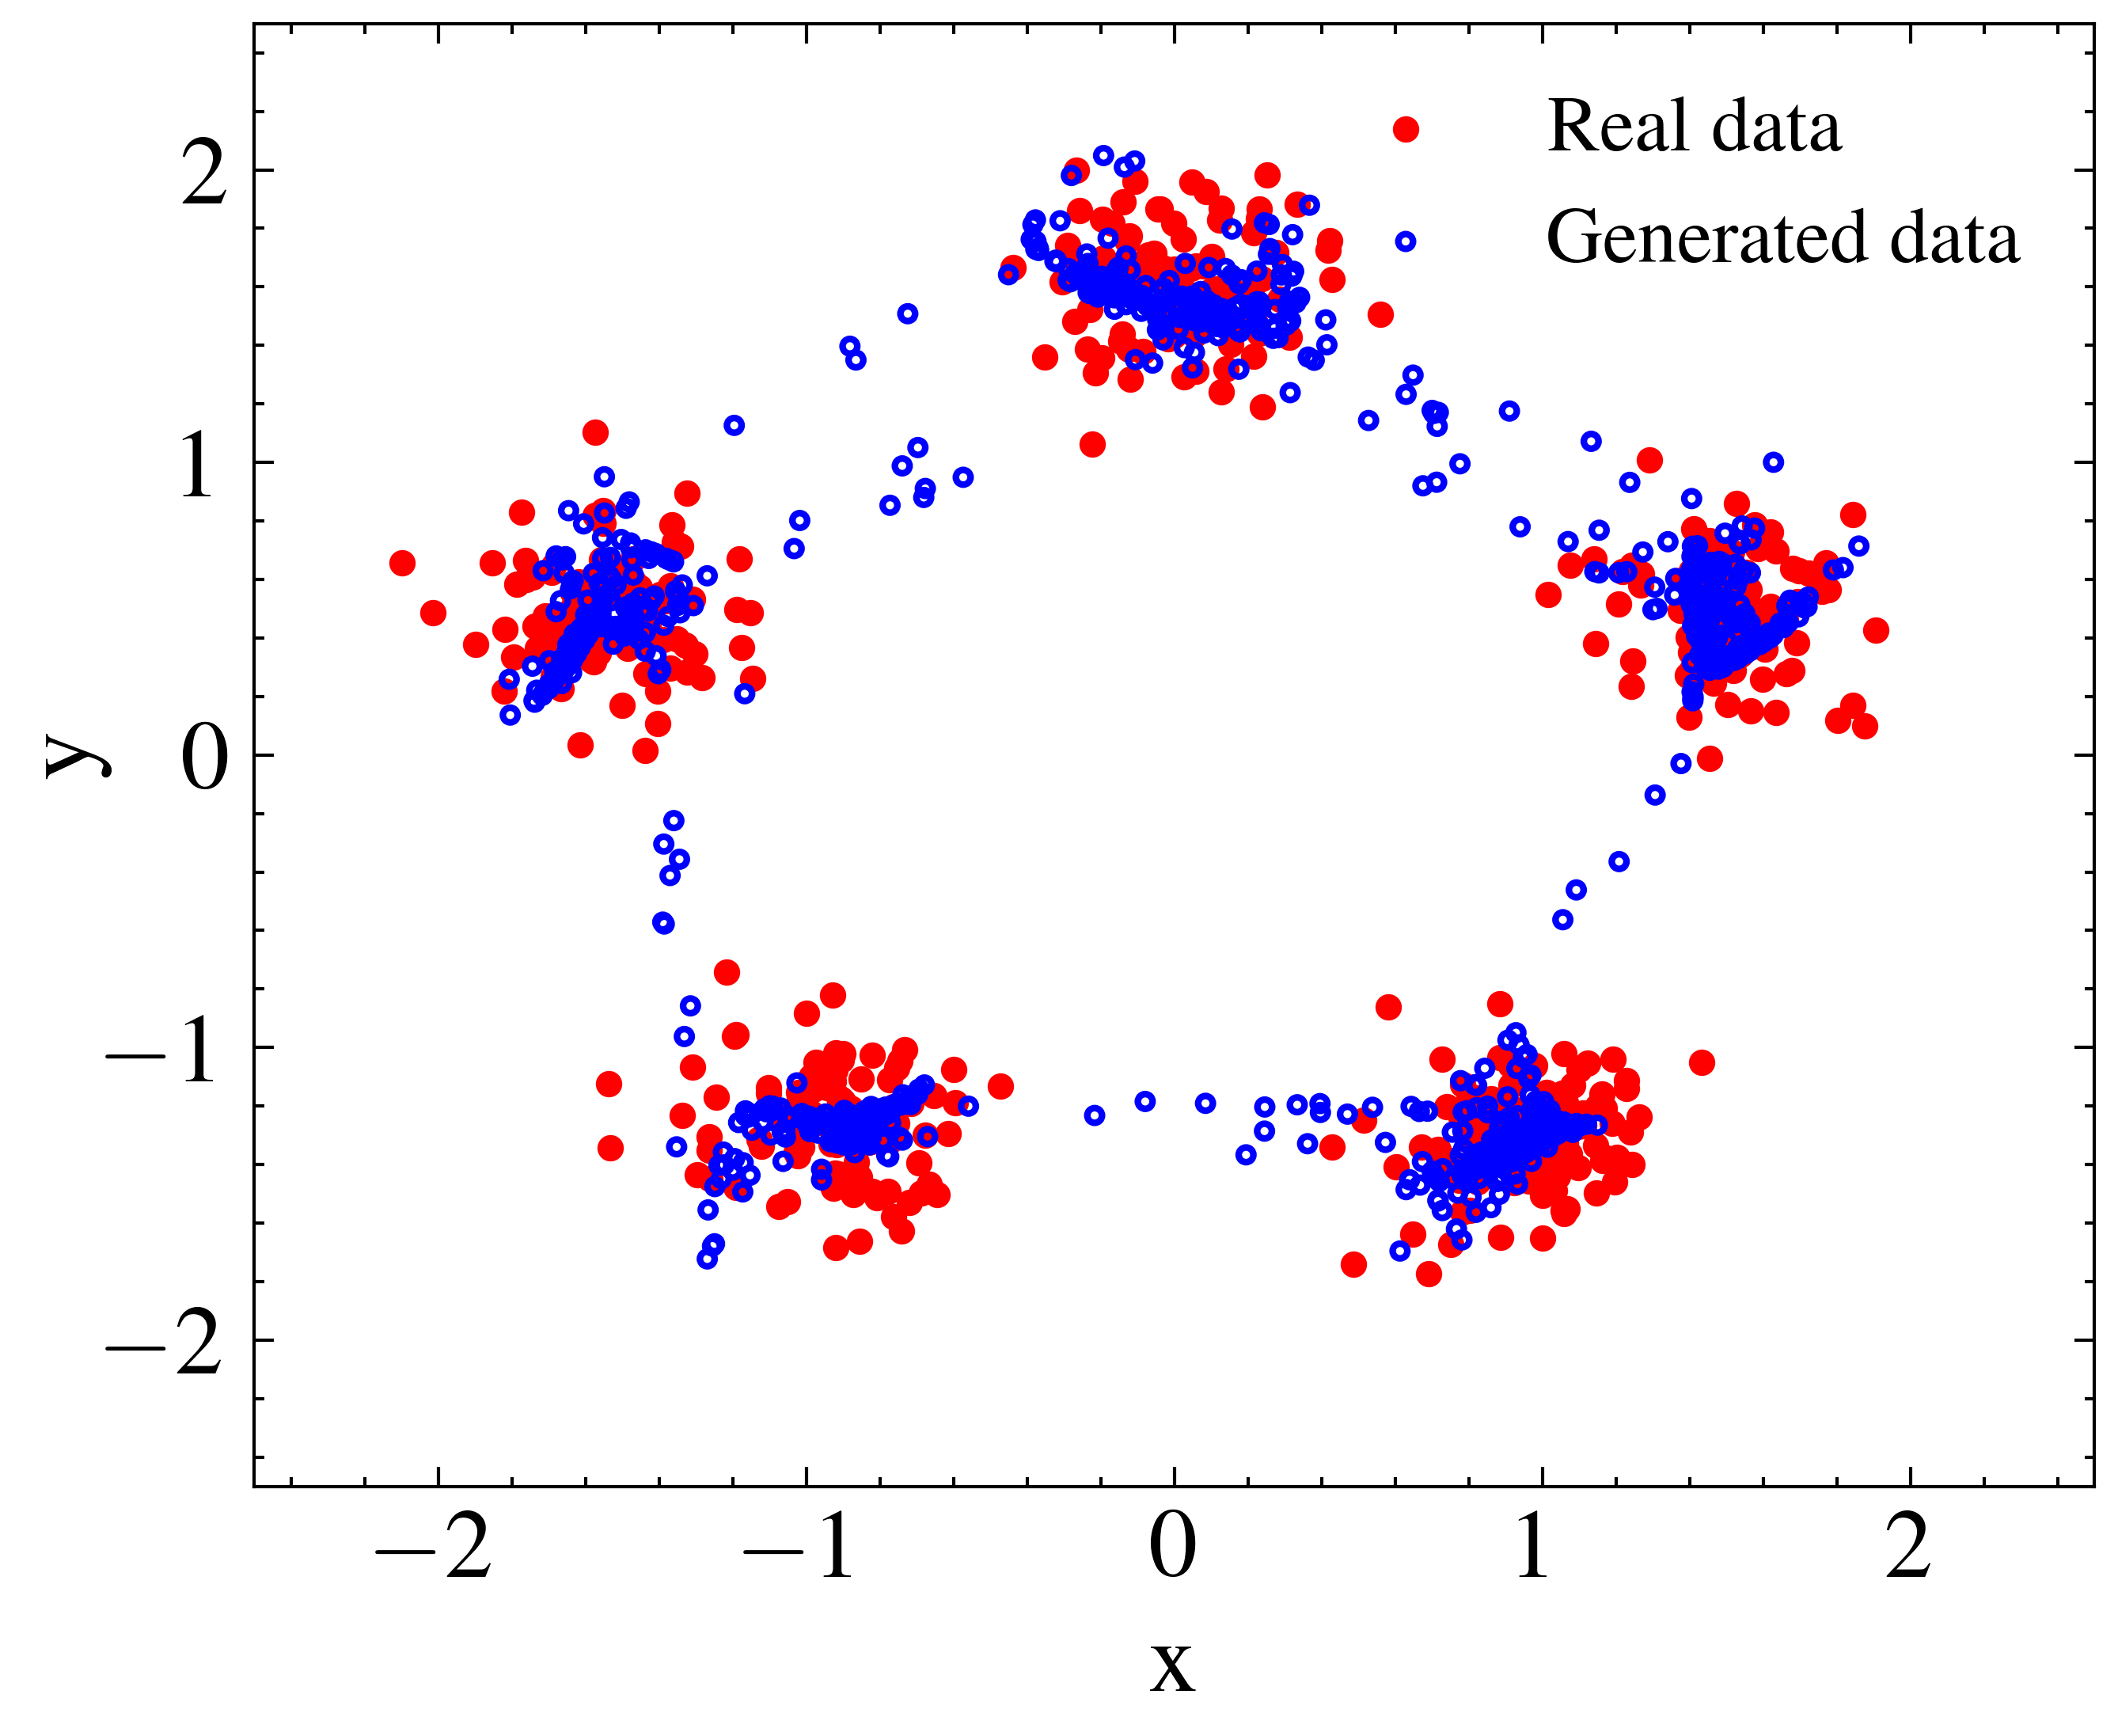


--- GAN 质量评价指标 ---
1-NN 分类精度（越接近0.5越好）: 1.0000
Coverage（真实样本被覆盖比例）: 0.8180
Precision（生成样本落入真实密度区域比例）: 0.9270


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import scienceplots
# 设置随机数种子
seed = 683###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Vsig(nn.Module):
    def __init__(self, init_sigma=0.5):  # 建议默认值就写 1.0（浮点数）
        super(Vsig, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = 1 / (1 + torch.exp(-input /sigma_safe ))
        return output

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.vsigmoid = Vsig()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.vsigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 10000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        # 重新生成图像（因为上面的fake_img已经detach了）
        fake_img = generator(z_input)
        d_fake, _ = discriminator(fake_img)
        
        # 直接使用判别器损失的相反数来训练生成器
        # 这将使生成器尝试最大化d_fake，欺骗判别器认为生成的样本是真实的
        g_loss = torch.mean(torch.log(1 - d_fake + 1e-8))

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
#ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_gan_quality(X_real, X_fake, eps=0.1):
    """
    评价 GAN 的输出质量，使用：
    - 1-NN 分类精度
    - Coverage 分数
    - Precision 分数（生成数据落入真实数据附近）

    参数：
    - X_real: (N, d) 真实样本
    - X_fake: (M, d) 生成样本
    - eps: 覆盖的距离阈值

    返回：
    - results: dict 包含各类指标
    """
    X_real = X_real.cpu().detach().numpy() if torch.is_tensor(X_real) else X_real
    X_fake = X_fake.cpu().detach().numpy() if torch.is_tensor(X_fake) else X_fake

    # ------------------------------
    # 1. 1-NN Classification Accuracy
    # ------------------------------
    X_all = np.concatenate([X_real, X_fake], axis=0)
    y_all = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_all, y_all)
    y_pred = knn.predict(X_all)
    acc = accuracy_score(y_all, y_pred)
    one_nn_acc = max(acc, 1 - acc)  # 对称性，靠近 0.5 越好

    # ------------------------------
    # 2. Coverage: 真实数据被生成样本覆盖的比例
    # ------------------------------
    dists_real_to_fake = cdist(X_real, X_fake)  # (N_real, N_fake)
    min_dists_real = np.min(dists_real_to_fake, axis=1)
    coverage_score = np.mean(min_dists_real < eps)

    # ------------------------------
    # 3. Precision: 生成样本落在真实样本附近的比例
    # ------------------------------
    dists_fake_to_real = cdist(X_fake, X_real)
    min_dists_fake = np.min(dists_fake_to_real, axis=1)
    precision_score = np.mean(min_dists_fake < eps)

    return {
        '1NN_acc': one_nn_acc,
        'Coverage': coverage_score,
        'Precision': precision_score
    }
# 生成样本
samples = generator(torch.randn(1000, z_dim)).detach()

# 调用评价函数
metrics = evaluate_gan_quality(X_train, samples, eps=0.1)

print("\n--- GAN 质量评价指标 ---")
print(f"1-NN 分类精度（越接近0.5越好）: {metrics['1NN_acc']:.4f}")
print(f"Coverage（真实样本被覆盖比例）: {metrics['Coverage']:.4f}")
print(f"Precision（生成样本落入真实密度区域比例）: {metrics['Precision']:.4f}")

In [15]:
print("Final sigma:", discriminator.vsigmoid.sigma.item())

Final sigma: 0.03215958923101425
